# QMC on Manifolds

## Setup

In [1]:
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import scipy.stats
import qmcpy as qp
import time
import os
# import qmcpy as qp
import matplotlib
from matplotlib import pyplot
pyplot.style.use("seaborn-v0_8-whitegrid")
# import pandas as pd
# COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv("../../../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
# pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
COLORS = ["xkcd:purple","xkcd:blue","xkcd:green","xkcd:red","xkcd:orange","xkcd:cyan","xkcd:brown","xkcd:yellow"]
LINESTYLES = ['solid','dotted','dashed','dashdot',(0, (1, 1))]
DEFAULTFONTSIZE = 30
pyplot.rcParams['xtick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['ytick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['ytick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['axes.titlesize'] = DEFAULTFONTSIZE
pyplot.rcParams['figure.titlesize'] = DEFAULTFONTSIZE
pyplot.rcParams["axes.labelsize"] = DEFAULTFONTSIZE
pyplot.rcParams['legend.fontsize'] = DEFAULTFONTSIZE
pyplot.rcParams['font.size'] = DEFAULTFONTSIZE
pyplot.rcParams['lines.linewidth'] = 5
pyplot.rcParams['lines.markersize'] = 15
PW = 30 # inches

## Sphere

In [2]:
class KernelSphereA(object):
    def __init__(self):
        self.integral = 2/3
    def __call__(self, x, y):
        assert x.size(-1)==3
        assert y.size(-2)==3
        y = 2-torch.linalg.norm(x-y,dim=-1)
        return y
class KernelShereB(object):
    def __init__(self):
        self.integral = 1-np.exp(-48)
    def __call__(self, x, y):
        assert x.size(-1)==3 
        assert y.size(-2)==3
        y = 48*torch.exp(-12*torch.linalg.norm(x-y,dim=-1)**2)
        return y
def unif_to_S2(x):
    assert x.size(-1)==2
    t = torch.sqrt(x[...,1]-x[...,1]**2)
    y = torch.stack([
        2*torch.cos(2*np.pi*x[...,0])*t,
        2*torch.sin(2*np.pi*x[...,0])*t,
        1-2*x[...,1]
        ],axis=-1)
    return y
def discrepancy(kernel, x, w):
    assert x.ndim>=2
    assert x.size(-2)==w.size(-1)
    kmat = kernel(x[...,:,None,:],x[...,None,:,:]) # (...,n,n)
    t1 = torch.einsum("...i,...ij,...j->...",w,kmat,w) # (...,)
    t2 = kernel.integral*(1-2*w.sum(-1))
    discrep = t1+t2 
    return discrep

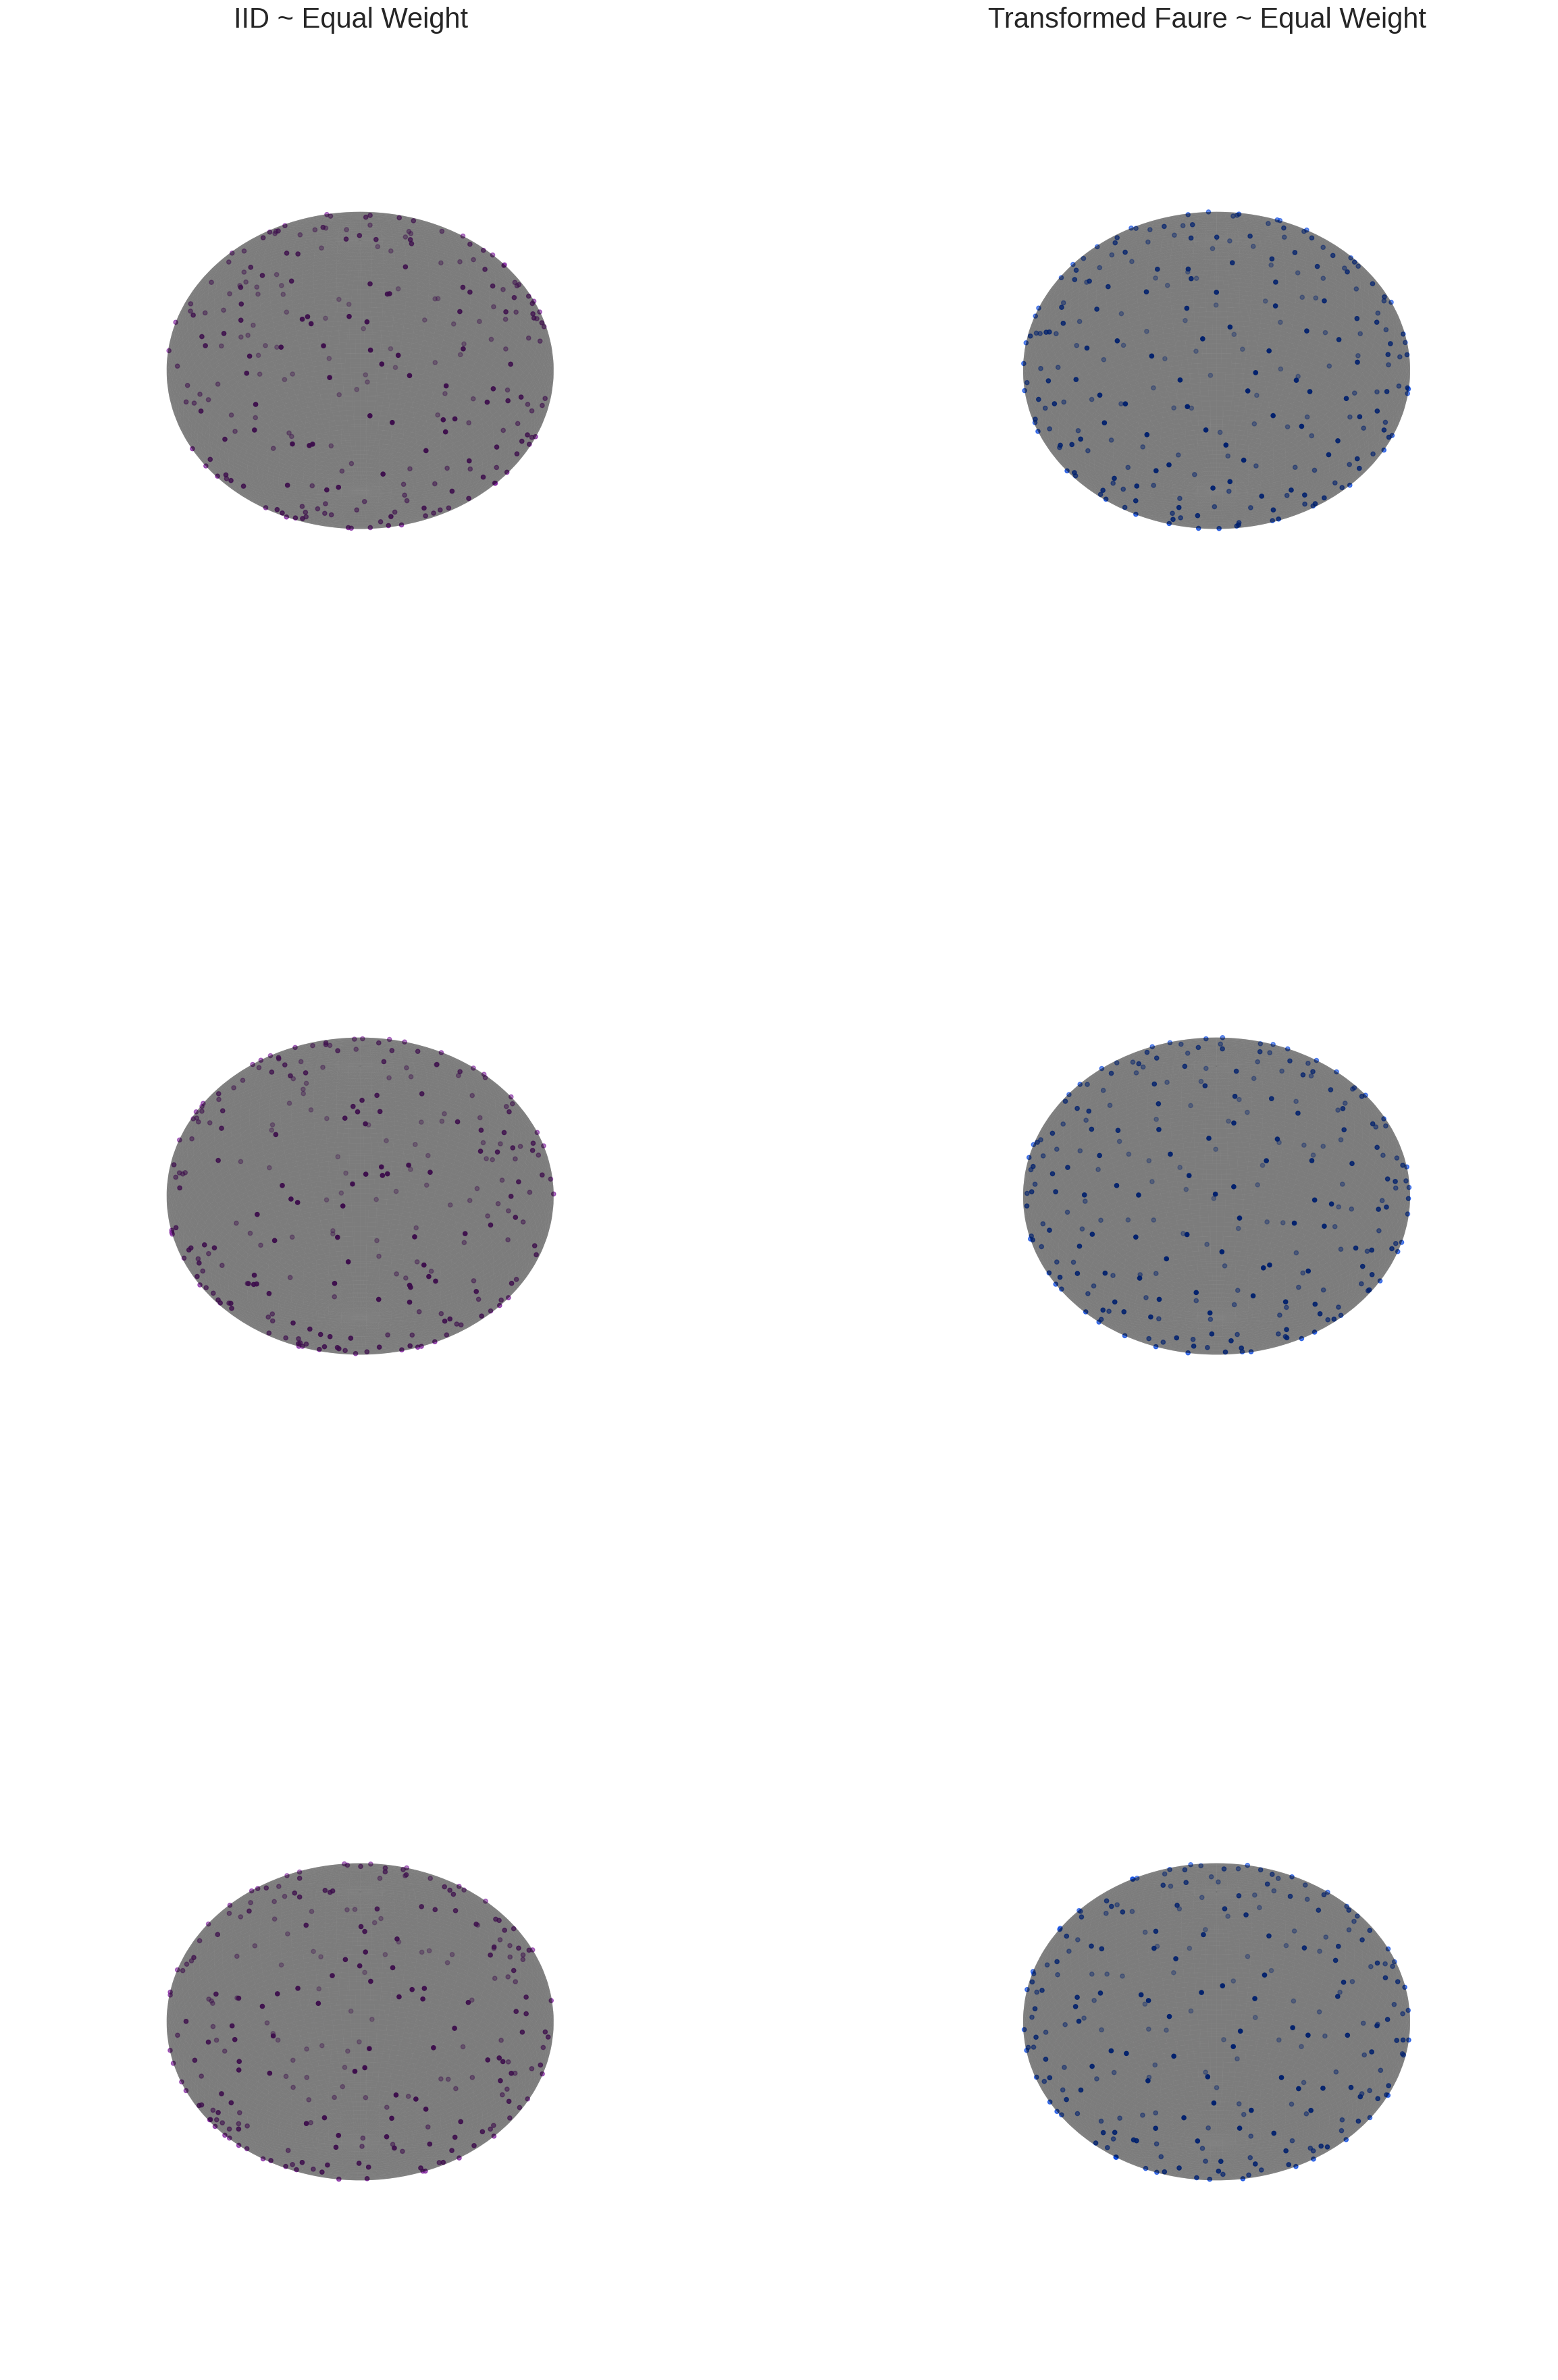

In [4]:
def get_spheres_fig_ax(nrows=1,ncols=1,showaxis=False,figwidth=PW,alpha=.3):
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(figwidth,figwidth/ncols*nrows),subplot_kw={"projection":"3d"})
    ax = np.atleast_1d(ax).reshape((nrows,ncols))
    phimesh,thetamesh = torch.meshgrid(torch.linspace(0,np.pi,100),torch.linspace(0,2*np.pi,100),indexing="ij")
    xmesh = torch.sin(phimesh)*torch.cos(thetamesh)
    ymesh = torch.sin(phimesh)*torch.sin(thetamesh)
    zmesh = torch.cos(phimesh)
    for i in range(nrows):
        for j in range(ncols):
            ax[i,j].plot_surface(xmesh,ymesh,zmesh,rstride=1,cstride=1,color='k',alpha=alpha,linewidth=0)
            if not showaxis:
                ax[i,j].axis("off");
    return fig,ax
rng = torch.Generator().manual_seed(17)
R = 3
n = 2**8
x_iid = unif_to_S2(torch.rand(R,n,2,generator=rng)) # (R,n,3)
x_ld = unif_to_S2(torch.from_numpy(qp.Faure(2,seed=17,randomize="NUS",replications=R)(n)))  # (R,n,3)
assert torch.allclose(torch.linalg.norm(x_iid,dim=-1),torch.ones(1))
assert torch.allclose(torch.linalg.norm(x_ld,dim=-1),torch.ones(1))
data = {
    "IID ~ Equal Weight": x_iid, 
    "Transformed Faure ~ Equal Weight": x_ld,
}
fig,ax = get_spheres_fig_ax(ncols=2,nrows=R,figwidth=PW)
for j,(key,x) in enumerate(data.items()):
    for r in range(x.size(0)):
        ax[r,j].scatter(x[r,:,0],x[r,:,1],x[r,:,2],color=COLORS[j])
    ax[0,j].set_title(key)